# Model Showdown: Flagging Likely Over-Threshold Income on Self-Reported Benefit Applications



## Dataset card

* **Name:** Adult / Census Income Data Set
* **Source:** US Census Bureau, 1994 Current Population Survey database
* **Collected / donated by:** Barry Becker and Ronny Kohavi (Silicon Graphics), donated 30 April 1996
* **Link:** https://archive.ics.uci.edu/dataset/2/adult
* **Licence:** Creative Commons Attribution 4.0 International (CC BY 4.0) — sharing and adaptation allowed with credit
* **Extraction filter applied by the original donors:** age > 16, adjusted gross income > \$100, final weight > 1, hours worked > 0
* **Size:** 48,842 rows (32,561 + 16,281 original train/test files, combined and re-split below), 14 raw features
* **Target:** `income`, binary — `>50K` vs `<=50K` (annual income, USD, 1994)
* **Class balance:** ≈ 76% `<=50K` / 24% `>50K`
* **Known limitations:** US population only, 1994 labour market, income reported/derived at individual level from a household survey, `fnlwgt` is a census sampling weight (not a trait of the person), 41 countries in `native_country` are very unevenly represented (≈90% United States).


In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import io
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score, confusion_matrix,
                              balanced_accuracy_score, roc_auc_score)

RANDOM_STATE = 42
MAIN_METRIC = "precision"   # chosen in Step 1, before any model is trained
np.random.seed(RANDOM_STATE)
print("Setup OK")


Setup OK


## Step 1 — Frame the problem

**Target:** whether a person's reported annual income is `>50K`

**Positive class:** `>50K`. This is the *minority* class (~24%), which matters for the baseline check in Step 5.

**Named user and decision:** an eligibility reviewer at a government
subsidy programme that is only available to applicants who earn **at or below** \$50K/year.
The model is used as a screen on *self-reported* income: if the model predicts an
applicant is actually `>50K` despite claiming otherwise, the application is **flagged for manual
document verification** . If the model predicts `<=50K`, the
application is approved


**Which mistake is worse?**

* **False positive** (model flags `>50K`, person is really `<=50K`): a genuinely eligible,
  low-income applicant is wrongly sent to manual verification, which causes delay and a risk
  they lose access to a subsidy they should get. This harms one specific, identifiable person.
* **False negative** (model predicts `<=50K`, person is really `>50K`): an ineligible, higher-income
  applicant gets a subsidy voucher they shouldn't have. This costs the
  programme budget, but does not deny support to anyone who needed it.

The false positive is definitely the worse mistake for this user, because it actively takes something away
from a person who qualifies for it.

**Main metric, chosen now, before training anything: Precision on the positive (`>50K`) class.**
High precision means that when we *do* flag someone for manual review, we are rarely wrong to
minimise mistakes for genuine low-income applicants. We will also report recall, F1,
balanced accuracy and ROC-AUC throughout, so that a model cannot "win" by simply refusing to flag
almost anyone (a model like that would also score badly on recall/F1, and we check for this
explicitly when we recommend a model in Step 9).


In [2]:
COLS = ["age", "workclass", "fnlwgt", "education", "education_num", "marital_status",
        "occupation", "relationship", "race", "sex", "capital_gain", "capital_loss",
        "hours_per_week", "native_country", "income"]

DATA_DIR = "data"
TRAIN_PATH = os.path.join(DATA_DIR, "adult.data")
TEST_PATH = os.path.join(DATA_DIR, "adult.test")
SOURCE_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/"

os.makedirs(DATA_DIR, exist_ok=True)
for fname, path in [("adult.data", TRAIN_PATH), ("adult.test", TEST_PATH)]:
    if not os.path.exists(path):
        print(f"{fname} not found locally, downloading from UCI ...")
        urllib.request.urlretrieve(SOURCE_URL + fname, path)
    else:
        print(f"{fname} found locally, skipping download.")


adult.data found locally, skipping download.
adult.test found locally, skipping download.


## Step 2 — Explore the data

Size, types, missing values, class balance, duplicates, and values that are really a
missing-value in disguise.


In [3]:
train_raw = pd.read_csv(TRAIN_PATH, header=None, names=COLS, skipinitialspace=True, na_values="?")
test_raw = pd.read_csv(TEST_PATH, header=None, names=COLS, skipinitialspace=True, na_values="?", skiprows=1)
test_raw["income"] = test_raw["income"].str.rstrip(".")  # adult.test labels end in a stray "."

# We combine the two official files into one raw pool and do our OWN stratified split in Step 3,
# instead of trusting the 1996 train/test split as-is -- that lets us de-duplicate across the
# whole pool first (see below), which the original split does not guarantee.
raw = pd.concat([train_raw, test_raw], ignore_index=True)
print("Combined raw shape:", raw.shape)
raw.head()


Combined raw shape: (48842, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
print(raw.dtypes)
print()
print("Missing values per column:")
print(raw.isna().sum()[raw.isna().sum() > 0])
print()
print("Class balance:")
print(raw["income"].value_counts(normalize=True).round(3))


age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
dtype: object

Missing values per column:
workclass         2799
occupation        2809
native_country     857
dtype: int64

Class balance:
income
<=50K    0.761
>50K     0.239
Name: proportion, dtype: float64


In [5]:
n_dupes = raw.duplicated().sum()
print(f"Exact duplicate rows in the combined pool: {n_dupes}")
print("These are dropped BEFORE the split in Step 3, so no duplicate can end up in both "
      "the train and the test set.")
raw = raw.drop_duplicates().reset_index(drop=True)
print("Shape after de-duplication:", raw.shape)


Exact duplicate rows in the combined pool: 52
These are dropped BEFORE the split in Step 3, so no duplicate can end up in both the train and the test set.
Shape after de-duplication: (48790, 15)


In [6]:
print(raw[["age", "hours_per_week", "capital_gain", "capital_loss"]].describe())


                age  hours_per_week  capital_gain  capital_loss
count  48790.000000    48790.000000  48790.000000  48790.000000
mean      38.652798       40.425886   1080.217688     87.595573
std       13.708493       12.392729   7455.905921    403.209129
min       17.000000        1.000000      0.000000      0.000000
25%       28.000000       40.000000      0.000000      0.000000
50%       37.000000       40.000000      0.000000      0.000000
75%       48.000000       45.000000      0.000000      0.000000
max       90.000000       99.000000  99999.000000   4356.000000


Two "impossible value in disguise" patterns, both documented census artefacts rather than data
errors (so we flag them and keep them, instead of silently dropping or trusting them):

* `hours_per_week` maxes at **99** so a value
  of 99 means "99 or more", not literally 99.
* `capital_gain` has a spike of **159 rows at exactly 99,999**. The same applied to
  capital gains for privacy reasons. If we just treated 99999 like a normal real number instead of flagging it as "this is a fake capped value," it would mess up how the models compare people — especially KNN, which decides how similar two people are based on how close their numbers are to each other.

None of the columns in this dataset could only be known after someone's income is already known. Things like age, job and education are known independently of income, so there's no
"cheating column" to remove here.

In [7]:
print("Rows with capital_gain == 99999 (top-coded):", (raw.capital_gain == 99999).sum())
print("Rows with hours_per_week == 99 (top-coded):", (raw.hours_per_week == 99).sum())


Rows with capital_gain == 99999 (top-coded): 244
Rows with hours_per_week == 99 (top-coded): 137


**Columns dropped, and why:**

* `fnlwgt` — It
  describes how the row was sampled, so it has no business being a
  predictive feature here.
* `education` — The same information as education_num, just as text
  instead of an ordinal number. Keeping both would duplicate one signal under two names.

**Column transformed:** `native_country` has 41 categories and is 90% United-States, so most
other categories have only a handful of rows. We made it into two categories, USA and Other, so the model gets a usable signal instead of dozens of almost empty columns.


In [8]:
raw["target"] = (raw["income"] == ">50K").astype(int)

X = raw.drop(columns=["income", "fnlwgt", "education"])
y = raw["target"]
X["native_country"] = np.where(X["native_country"] == "United-States", "United-States", "Other")

NUM_FEATURES = ["age", "education_num", "capital_gain", "capital_loss", "hours_per_week"]
CAT_FEATURES = ["workclass", "marital_status", "occupation", "relationship", "race", "sex", "native_country"]

print("Final feature set:", NUM_FEATURES + CAT_FEATURES, f"({len(NUM_FEATURES) + len(CAT_FEATURES)} features)")
print("Target positive rate (>50K):", round(y.mean(), 4))


Final feature set: ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country'] (12 features)
Target positive rate (>50K): 0.2394


## Step 3 — Split first

We split off 20% of the data as a test set that the models never see during training, so we can
check them honestly later. Both parts keep the same ~76/24 income mix, and we
lock a fixed random seed so the split is identical every time.

The split is used after step 7.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train positive rate:", round(y_train.mean(), 4), " Test positive rate:", round(y_test.mean(), 4))


Train: (39032, 13)  Test: (9758, 13)
Train positive rate: 0.2394  Test positive rate: 0.2394


Three cleanup steps, done automatically, only using training data:

* **Filling in blanks:** some columns have unknown values marked
  "?". Instead of guessing "probably the most common answer," we just label them "Missing".
* **Putting numbers on the same scale:** `capital_gain` can be up to 99,999, while `age` only goes
  up to 90. Without rescaling, KNN and Logistic Regression would basically only pay attention to
  capital_gain and ignore age, just because its numbers are bigger — not because it's actually more
  important. Random Forest doesn't care about this, but we scale everything the same way for all
  three models anyway, so it's a fair comparison.
* **Turning categories into numbers:** things like job titles get converted into a format the
  models can actually use.

In [10]:
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), NUM_FEATURES),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), CAT_FEATURES),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("Preprocessor and CV scheme ready.")


Preprocessor and CV scheme ready.


## Step 5 — Baseline

This is our "dumb model". It just always guesses the most common answer. Every real model has to beat this to prove it's actually doing something useful.

Normally, with data like this (most people earn <=50K), a dumb "always guess <=50K" model can look
decent on accuracy without actually being smart. But because we're scoring on precision for
the ">50K" group specifically, and the dumb model never guesses ">50K" at all, it scores a flat
0.0. It can't fake a good score here. So any real score above 0 from here on is actual progress.



In [11]:
baseline = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline_cv = cross_validate(baseline, X_train, y_train, cv=cv, scoring=MAIN_METRIC)
baseline.fit(X_train, y_train)
print(f"Baseline CV precision: {baseline_cv['test_score'].mean():.3f} +/- {baseline_cv['test_score'].std():.3f}")


Baseline CV precision: 0.000 +/- 0.000


## Step 6 — Tune with cross-validation

To tune each model fairly, we split the training data into 5 chunks, train on 4 and test on the
1 left over, then rotate so every part of the dataset gets tested once.
The exact same scoring rule (precision) for all three models. The only thing that changes between
models is the model itself and the setting we're testing for it.


In [12]:
knn_pipe = Pipeline([("prep", preprocessor), ("clf", KNeighborsClassifier(n_jobs=1))])
knn_grid = {"clf__n_neighbors": [5, 11, 21, 31, 51, 75], "clf__weights": ["uniform", "distance"]}
knn_search = GridSearchCV(knn_pipe, knn_grid, scoring=MAIN_METRIC, cv=cv, n_jobs=2)
knn_search.fit(X_train, y_train)
print("KNN best params:", knn_search.best_params_)
print(f"KNN best CV precision: {knn_search.best_score_:.3f}")


KNN best params: {'clf__n_neighbors': 51, 'clf__weights': 'uniform'}
KNN best CV precision: 0.717


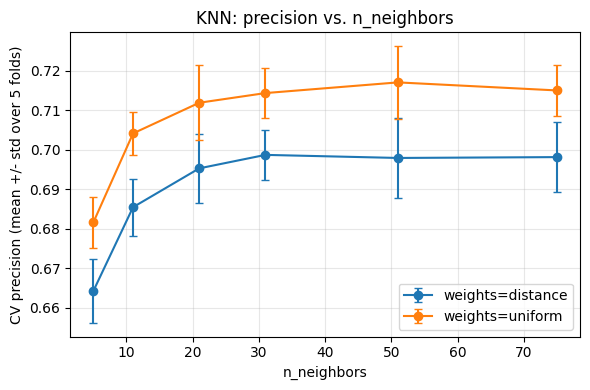

In [13]:
res = pd.DataFrame(knn_search.cv_results_)
fig, ax = plt.subplots(figsize=(6, 4))
for w, sub in res.groupby("param_clf__weights"):
    sub = sub.sort_values("param_clf__n_neighbors")
    ax.errorbar(sub["param_clf__n_neighbors"], sub["mean_test_score"], yerr=sub["std_test_score"],
                marker="o", capsize=3, label=f"weights={w}")
ax.set_xlabel("n_neighbors")
ax.set_ylabel("CV precision (mean +/- std over 5 folds)")
ax.set_title("KNN: precision vs. n_neighbors")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [14]:
logreg_pipe = Pipeline([("prep", preprocessor), ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))])
logreg_grid = {"clf__C": [0.001, 0.01, 0.1, 1, 10, 100]}
logreg_search = GridSearchCV(logreg_pipe, logreg_grid, scoring=MAIN_METRIC, cv=cv, n_jobs=2)
logreg_search.fit(X_train, y_train)
print("Logistic Regression best params:", logreg_search.best_params_)
print(f"Logistic Regression best CV precision: {logreg_search.best_score_:.3f}")


Logistic Regression best params: {'clf__C': 0.001}
Logistic Regression best CV precision: 0.755


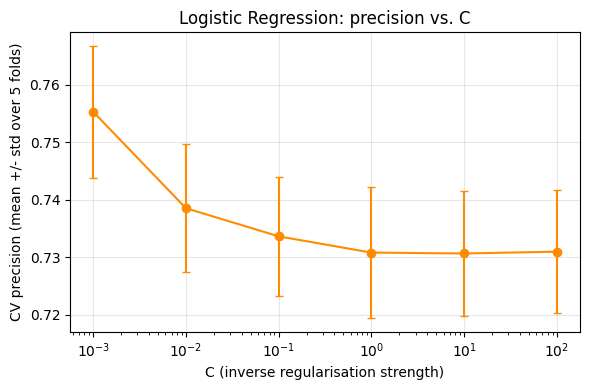

In [15]:
res = pd.DataFrame(logreg_search.cv_results_).sort_values("param_clf__C")
fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(res["param_clf__C"].astype(float), res["mean_test_score"], yerr=res["std_test_score"],
            marker="o", capsize=3, color="darkorange")
ax.set_xscale("log")
ax.set_xlabel("C (inverse regularisation strength)")
ax.set_ylabel("CV precision (mean +/- std over 5 folds)")
ax.set_title("Logistic Regression: precision vs. C")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Third model: Random Forest.** This model is basically a big group of decision trees that each
vote, and we go with the majority vote. We picked it because it can notice combinations of things
mattering together (like job + hours + education together affecting income in ways a straight-line
model can't catch), while still being easy enough to explain.


In [16]:
rf_pipe = Pipeline([("prep", preprocessor),
                     ("clf", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=1))])
rf_grid = {"clf__max_depth": [3, 5, 8, 12, 20, 30]}
rf_search = GridSearchCV(rf_pipe, rf_grid, scoring=MAIN_METRIC, cv=cv, n_jobs=2)
rf_search.fit(X_train, y_train)
print("Random Forest best params:", rf_search.best_params_)
print(f"Random Forest best CV precision: {rf_search.best_score_:.3f}")


Random Forest best params: {'clf__max_depth': 3}
Random Forest best CV precision: 0.905


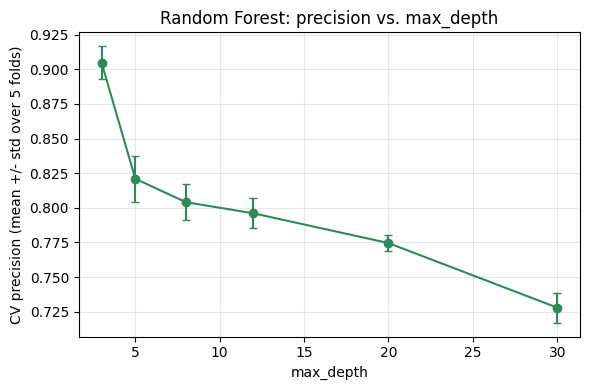

In [17]:
res = pd.DataFrame(rf_search.cv_results_).sort_values("param_clf__max_depth")
fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(res["param_clf__max_depth"], res["mean_test_score"], yerr=res["std_test_score"],
            marker="o", capsize=3, color="seagreen")
ax.set_xlabel("max_depth")
ax.set_ylabel("CV precision (mean +/- std over 5 folds)")
ax.set_title("Random Forest: precision vs. max_depth")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [18]:
searches = {"KNN": knn_search, "Logistic Regression": logreg_search, "Random Forest": rf_search}

cv_summary = [{
    "model": "Baseline (most frequent)",
    "best_params": "-",
    "cv_precision_mean": baseline_cv["test_score"].mean(),
    "cv_precision_std": baseline_cv["test_score"].std(),
}]
for name, search in searches.items():
    cv_summary.append({
        "model": name,
        "best_params": search.best_params_,
        "cv_precision_mean": search.best_score_,
        "cv_precision_std": search.cv_results_["std_test_score"][search.best_index_],
    })
cv_summary_df = pd.DataFrame(cv_summary)
cv_summary_df


,model,best_params,cv_precision_mean,cv_precision_std
0,Baseline (most frequent),-,0.000000,0.000000
1,KNN,"{'clf__n_neighbors': 51, 'clf__weights': 'unif...",0.717091,0.009183
2,Logistic Regression,{'clf__C': 0.001},0.755307,0.011442
3,Random Forest,{'clf__max_depth': 3},0.904761,0.011925


All three real models score way higher than the dumb baseline. So this is a
real difference because the models are actually learning something, not just random luck.

## Step 7 — Evaluate once on the test set

Now we use the test set from Step 3 for real, once, per model: a table of right/wrong guesses,
a few different scores, and a comparison of train vs. tuning vs. test scores — if those numbers
are wildly different, the model either memorised the training data or never really learned it.


In [19]:
def evaluate_once(name, estimator, X_tr, y_tr, X_te, y_te):
    y_pred_tr = estimator.predict(X_tr)
    y_pred_te = estimator.predict(X_te)
    row = {
        "model": name,
        "train_precision": precision_score(y_tr, y_pred_tr, zero_division=0),
        "test_precision": precision_score(y_te, y_pred_te, zero_division=0),
        "test_recall": recall_score(y_te, y_pred_te, zero_division=0),
        "test_f1": f1_score(y_te, y_pred_te, zero_division=0),
        "test_balanced_acc": balanced_accuracy_score(y_te, y_pred_te),
    }
    try:
        proba = estimator.predict_proba(X_te)[:, 1]
        row["test_roc_auc"] = roc_auc_score(y_te, proba)
    except Exception:
        row["test_roc_auc"] = np.nan
    cm = confusion_matrix(y_te, y_pred_te)
    return row, cm

results = []
cms = {}
row, cm = evaluate_once("Baseline", baseline, X_train, y_train, X_test, y_test)
results.append(row); cms["Baseline"] = cm
for name, search in searches.items():
    row, cm = evaluate_once(name, search.best_estimator_, X_train, y_train, X_test, y_test)
    results.append(row); cms[name] = cm

results_df = pd.DataFrame(results)
# attach the CV mean/std from Step 6 so train / CV / test sit side by side
results_df = results_df.merge(
    cv_summary_df[["model", "cv_precision_mean", "cv_precision_std"]],
    on="model", how="left"
)
cols_order = ["model", "train_precision", "cv_precision_mean", "cv_precision_std", "test_precision",
              "test_recall", "test_f1", "test_balanced_acc", "test_roc_auc"]
results_df = results_df[cols_order].round(3)
results_df


,model,train_precision,cv_precision_mean,cv_precision_std,test_precision,test_recall,test_f1,test_balanced_acc,test_roc_auc
0,Baseline,0.000,NaN,NaN,0.000,0.000,0.000,0.500,0.500
1,KNN,0.733,0.717,0.009,0.728,0.624,0.672,0.775,0.905
2,Logistic Regression,0.753,0.755,0.011,0.756,0.488,0.593,0.719,0.897
3,Random Forest,0.903,0.905,0.012,0.906,0.287,0.436,0.639,0.894


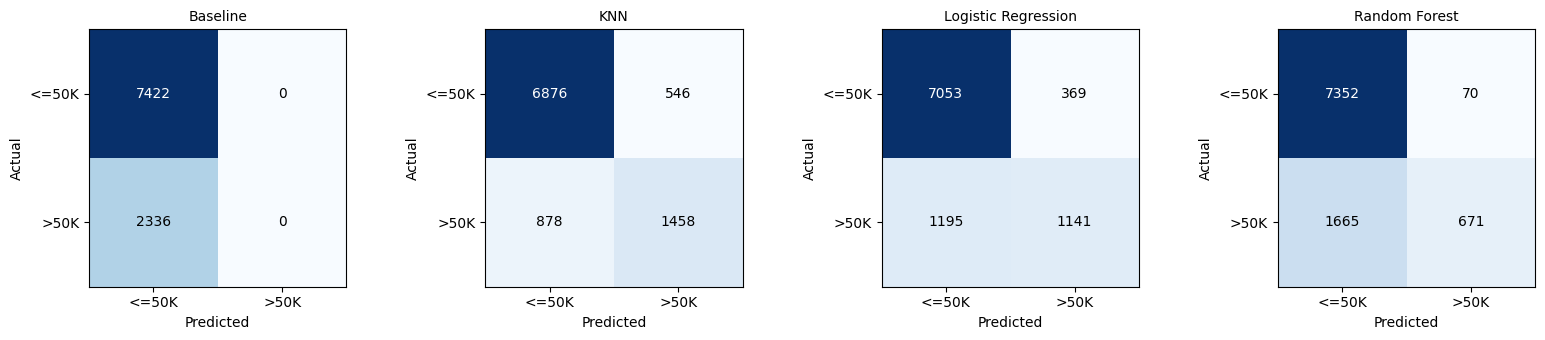

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, name in zip(axes, cms):
    cm = cms[name]
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["<=50K", ">50K"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["<=50K", ">50K"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(name, fontsize=10)
plt.tight_layout()
plt.show()


**Train vs. tuning vs. test scores:** these three numbers are close together for all three models.
Which is good because it means none of them just memorised the training data and then failed on new data.

**But precision alone doesn't tell the whole story — look at recall too:** Random Forest has the
best precision (0.91) but the worst recall (0.29) — it misses 7 out of 10 real high earners.
Logistic Regression also trades recall for precision: its best setting barely catches half of real
high earners (0.49 recall) to get 0.76 precision. KNN has slightly lower precision (0.73) but
clearly catches more real cases (0.63 recall) and scores better overall. Step 9 has to decide if
that trade-off is worth it.

### Comparison table (required deliverable, all in one place)

Everything the assignment's submission checklist asks for, in one table: best hyperparameters, the cross-validation score (mean +/- spread), and the test precision/recall/F1, baseline first.


In [19]:
comparison_table = results_df.merge(
    cv_summary_df[["model", "best_params"]], on="model", how="left"
)[["model", "best_params", "cv_precision_mean", "cv_precision_std",
   "test_precision", "test_recall", "test_f1"]]
print(comparison_table.to_string(index=False))


                   model                               best_params  cv_precision_mean  cv_precision_std  test_precision  test_recall  test_f1
Baseline (most frequent)                                         -              0.000             0.000           0.000        0.000    0.000
                     KNN {'n_neighbors': 51, 'weights': 'uniform'}              0.717             0.009           0.728        0.624    0.672
     Logistic Regression                              {'C': 0.001}              0.755             0.011           0.756        0.488    0.593
           Random Forest {'max_depth': 3} (n_estimators=200 fixed)              0.905             0.012           0.906        0.287    0.436


## Step 8 — Look at the errors

First, a few concrete examples of wrong guesses from KNN (the model we end up recommending in
Step 9). Then we check whether every model makes mistakes equally for everyone, by splitting
results by sex and by country (US-born vs. not)


In [21]:
recommended_model = searches["KNN"].best_estimator_  # see Step 9 for why
y_pred = recommended_model.predict(X_test)
inspect = X_test.copy()
inspect["y_true"] = y_test.values
inspect["y_pred"] = y_pred

print("False positives -- flagged for review, but really <=50K:")
print(inspect[(inspect.y_pred == 1) & (inspect.y_true == 0)]
      [["age", "workclass", "education_num", "occupation", "hours_per_week", "sex"]].head(3))

print()
print("False negatives -- not flagged, but really >50K:")
print(inspect[(inspect.y_pred == 0) & (inspect.y_true == 1)]
      [["age", "workclass", "education_num", "occupation", "hours_per_week", "sex"]].head(3))


False positives -- flagged for review, but really <=50K:
       age workclass  education_num       occupation  hours_per_week   sex
21627   45   Private             13            Sales              55  Male
34886   42   Private             11  Exec-managerial              40  Male
20119   44   Private              9            Sales              68  Male

False negatives -- not flagged, but really >50K:
       age  workclass  education_num         occupation  hours_per_week  \
11391   45    Private              9  Handlers-cleaners              40   
24274   43  State-gov             10       Adm-clerical              50   
35517   28    Private              9       Tech-support              40   

          sex  
11391    Male  
24274    Male  
35517  Female  


The "wrongly flagged" cases above look like genuine near-misses. Like mid-career people with decent
jobs and education who just happen to fall slightly under the line. Not weird mistakes, reasonable
ones.

The "missed" cases tend to have lower education levels and more clerical/service jobs. The model
assumes people with that profile don't earn over $50K — and is wrong often enough that it's worth
remembering when we look at the group breakdown below.

In [22]:
def subgroup_report(name, estimator, X_te, y_te, group_col, min_n=20):
    y_pred = estimator.predict(X_te)
    df = X_te.copy()
    df["y_true"] = y_te.values
    df["y_pred"] = y_pred
    rows = []
    for g, sub in df.groupby(group_col):
        if len(sub) < min_n:
            continue
        n_neg = (sub["y_true"] == 0).sum()
        fp = ((sub["y_pred"] == 1) & (sub["y_true"] == 0)).sum()
        rows.append({
            "model": name, "group": g, "n": len(sub),
            "precision": precision_score(sub["y_true"], sub["y_pred"], zero_division=0),
            "recall": recall_score(sub["y_true"], sub["y_pred"], zero_division=0),
            "false_positive_rate": fp / n_neg if n_neg else np.nan,
        })
    return rows

sex_rows, country_rows = [], []
for name, est in {**{k: v.best_estimator_ for k, v in searches.items()}, "Baseline": baseline}.items():
    sex_rows += subgroup_report(name, est, X_test, y_test, "sex")
    country_rows += subgroup_report(name, est, X_test, y_test, "native_country")

sex_df = pd.DataFrame(sex_rows).round(3)
country_df = pd.DataFrame(country_rows).round(3)
print("--- by sex ---")
display_sex = sex_df.pivot(index="model", columns="group", values=["precision", "recall", "false_positive_rate"])
print(display_sex)


--- by sex ---
                    precision        recall        false_positive_rate       
group                  Female   Male Female   Male              Female   Male
model                                                                        
Baseline                0.000  0.000  0.000  0.000               0.000  0.000
KNN                     0.781  0.720  0.475  0.653               0.017  0.111
Logistic Regression     0.905  0.747  0.198  0.545               0.003  0.081
Random Forest           1.000  0.902  0.063  0.331               0.000  0.016


In [23]:
print("--- by native_country (United-States vs. Other) ---")
display_country = country_df.pivot(index="model", columns="group", values=["precision", "recall", "false_positive_rate"])
print(display_country)


--- by native_country (United-States vs. Other) ---
                    precision               recall                \
group                   Other United-States  Other United-States   
model                                                              
Baseline                0.000         0.000  0.000         0.000   
KNN                     0.791         0.722  0.607         0.626   
Logistic Regression     0.761         0.755  0.510         0.486   
Random Forest           0.917         0.904  0.320         0.284   

                    false_positive_rate                
group                             Other United-States  
model                                                  
Baseline                          0.000         0.000  
KNN                               0.040         0.078  
Logistic Regression               0.040         0.051  
Random Forest                     0.007         0.010  


**This is the most important finding for Step 9.** Every model is worse at catching high-earning
women than high-earning men (high income is rarer for women in this old data, so
there's less to learn from). But HOW BAD the gap is differs a lot per model:

* **Random Forest** (looked "best" overall): catches only 6% of real high-earning women, vs. 33%
  of men. Basically misses almost all of them.
* **Logistic Regression** (looked "second-best"): catches 20% of women vs. 55% of men — the
  biggest gap of all three models.
* **KNN** (looked "worst" overall): catches 47% of women vs. 66% of men — still a gap, but by far
  the smallest, and the best result for women of any model.

So the two models that scored better on our main number are actually the two that fail women the
most. KNN, which scored lowest, treats both groups the most fairly.

## Step 9 — Recommendation

**Not Random Forest**, even though it had the best score on our own chosen number (precision
0.90 vs 0.72-0.76 for the others).
Because it only catches 29% of real high earners overall, and just 6% of high-earning women. Its
good score is mostly because it barely ever guesses "yes" at all, so it's rarely wrong but not useful.

**Also not Logistic Regression**, even though it came in second on our number (0.76). Its best
setting also makes it play it very safe, meaning it only catches about half of real high earners, and
has the worst gap between men and women of all three models (55% of men caught vs. only 20% of
women).

**Recommendation: KNN.** It scored the lowest on our main number (0.73), but it catches far more
real high earners (63%), scores best overall, and treats men and women the most evenly of the
three (66% vs. 47%, still a gap, but way smaller than the other two). It's harder to explain in
one sentence than Logistic Regression, but that's a smaller downside than picking a model that
barely works for half the people it's judging.

**The decision I would defend:** I picked precision as my main score before training anything, then still rejected the two models that scored highest on it. Picking a metric upfront doesn't
mean blindly obeying it later; it means being honest that scoring best on paper isn't the same as
actually being the right model to use.

## Step 10 — Use it

Here we make up a fake person and run them through the whole process automatically. That's the whole reason we built this as
one "pipeline" earlier: so we can throw a new person at it and get an answer without redoing all
the cleaning steps by hand.

The model gives two things: a yes/no guess, and a confidence percentage. For KNN specifically,
that percentage is just: out of the 51 most similar people in our training data, what % of them
actually earned over $50K.


In [24]:
new_applicant = pd.DataFrame([{
    "age": 34,
    "workclass": "Private",
    "marital_status": "Never-married",
    "occupation": "Prof-specialty",
    "relationship": "Not-in-family",
    "race": "White",
    "sex": "Female",
    "capital_gain": 0,
    "capital_loss": 0,
    "hours_per_week": 45,
    "native_country": "United-States",
    "education_num": 13,
}])[NUM_FEATURES + CAT_FEATURES]

pred = recommended_model.predict(new_applicant)[0]
proba = recommended_model.predict_proba(new_applicant)[0, 1]

print("New applicant:")
print(new_applicant.to_string(index=False))
print()
label = ">50K (flag for manual income verification)" if pred == 1 else "<=50K (fast-track, no flag)"
print(f"Prediction: {label}")
print(f"P(income > 50K) = {proba:.3f}")


New applicant:
 age  education_num  capital_gain  capital_loss  hours_per_week workclass marital_status     occupation  relationship  race    sex native_country
  34             13             0             0              45   Private  Never-married Prof-specialty Not-in-family White Female  United-States

Prediction: <=50K (fast-track, no flag)
P(income > 50K) = 0.078
